# Optimal Backhaul Bandwidth Allocation Across Service Classes (Quadratic Program)

## Executive Summary

A regional mobile operator must split a fixed **100 Gbps** backhaul link across five
traffic classes (voice, streaming video, web, IoT/M2M, enterprise VPN) so as to
**minimize a convex congestion-plus-handling cost** subject to a capacity ceiling,
a regulatory voice floor, an enterprise SLA floor, and an IoT policy cap. Because the
objective is quadratic and convex while every constraint is linear, this is a
**quadratic program (QP)**, solved here with `PROC OPTMODEL`'s `SOLVE WITH QP`.

The solver returns an optimal plan with objective value **-388.03** (a negative cost,
i.e. a net margin of \$388.03 per unit time). The recommended allocation is
**voice 26.26, streaming 15.84, web 14.18, IoT 20.00, VPN 23.71 Gbps**, which exactly
saturates the 100 Gbps link. Two constraints bind at the optimum — the **capacity
ceiling** and the **IoT cap** (IoT is pushed to its 20 Gbps limit) — while the voice
and VPN floors are slack, meaning the cost-minimizing plan already carries far more
voice and VPN than the regulatory and SLA minimums require.

## The model

Each class \(c\) is allocated `alloc[c]` Gbps. Carrying traffic earns a per-Gbps
**margin** (modeled as a negative cost coefficient), but congestion cost grows with the
**square** of a class's utilization — queueing delay, retransmission, and jitter all
worsen super-linearly as a class is pushed harder. Streaming and web additionally share
CDN edge-cache resources, so loading both heavily incurs an extra interaction penalty.

**Objective (minimize):**

```
cost =  sum_c ( margin[c]*alloc[c] + 0.5*curv[c]*alloc[c]^2 )
      + 0.10 * alloc[streaming] * alloc[web]      (shared-CDN cross term)
```

| Class | `margin` (\$/Gbps) | `curv` (congestion curvature) |
|-------|--------------------:|------------------------------:|
| voice     | -8.34 | 0.30 |
| streaming | -9.01 | 0.45 |
| web       | -7.01 | 0.35 |
| IoT/M2M   | -5.16 | 0.20 |
| VPN       | -6.39 | 0.25 |

**Constraints:**

```
cap   : sum_c alloc[c] <= 100   (backhaul capacity ceiling)
voice : alloc[voice]   >=  12   (regulatory voice floor)
vpn   : alloc[vpn]     >=  15   (enterprise SLA floor)
iot   : alloc[iot]     <=  20   (IoT/M2M policy cap)
```

The margins above include a small fixed per-class jitter so the example is concrete;
the structural curvatures and the cross-term are the analytically meaningful inputs.

> **A note on PROC OPTQP.** SAS solves QPS-format quadratic programs with the dedicated
> `PROC OPTQP`. That procedure is not yet available in this Jenner build, so this
> notebook expresses the identical convex QP through `PROC OPTMODEL` with
> `SOLVE WITH QP`, stated in OPTMODEL's algebraic modeling syntax rather than QPS card
> images. Because the objective is quadratic (non-linear), `SOLVE WITH QP` hands the
> model to OPTMODEL's nonlinear solver — the Solution Summary below reports
> `Objective Type: Nonlinear` and `Solver: NLP`. The convex objective guarantees the
> returned point is the global optimum, so the optimal allocation and objective match
> what OPTQP would return for the same QP.

## Step 1 — Solve the QP with PROC OPTMODEL

We declare one non-negative decision variable per traffic class, write the convex
quadratic objective, add the four linear constraints, and call `SOLVE WITH QP`. The
optimal allocation is written to a one-row data set for downstream reporting.

In [1]:
proc optmodel;
    /* Decision variables: Gbps per traffic class, non-negative */
    var v >= 0;   /* voice / VoLTE   */
    var s >= 0;   /* streaming video */
    var w >= 0;   /* web / browsing  */
    var m >= 0;   /* IoT / M2M       */
    var e >= 0;   /* enterprise VPN  */

    /* Minimize congestion-plus-handling cost:
       linear margins (negative = revenue per Gbps), convex quadratic
       congestion, and a streaming-web cross-term for shared CDN edge cache. */
    min cost =
          -8.34*v - 9.01*s - 7.01*w - 5.16*m - 6.39*e
        + 0.5*( 0.30*v^2 + 0.45*s^2 + 0.35*w^2 + 0.20*m^2 + 0.25*e^2 )
        + 0.10*s*w;

    con cap:   v + s + w + m + e <= 100;   /* backhaul capacity ceiling */
    con voice: v >= 12;                     /* regulatory voice floor    */
    con vpn:   e >= 15;                     /* enterprise SLA floor      */
    con iot:   m <= 20;                     /* IoT/M2M policy cap        */

    solve with qp;

    print v s w m e cost;
    num used = v + s + w + m + e;
    put 'Capacity used = ' used ' of 100 Gbps';

    /* Persist the optimal allocation (one wide row) for reporting */
    create data qp_wide from v=v s=s w=w m=m e=e cost=cost;
quit;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            COST
  Objective Type                Nonlinear

  Number of Variables           5
  Bounded Above                 0
  Bounded Below                 5
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         4

                          Solution Summary
  Solver                        NLP
  Objective Function            COST
  Solution Status               Optimal
  Objective Value               -388.0289226957

  Capacity used =  100  of 100 Gbps
  V              S              W              M              E           COST

  26.2607        15.8444        14.1822           20.0        23.7128      -388.0289



NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.17.1
NOTE: PROC OPTMODEL completed.


## Step 2 — Reshape the solution into a per-class plan

The `PROC OPTMODEL` step wrote one wide row. A short DATA step reshapes it into a tidy
long table — one observation per traffic class — and tags which constraint, if any, is
binding at the optimum.

In [2]:
data qp_alloc;
    set qp_wide;
    length traffic_class $12 binding $28;
    array vals[5] v s w m e;
    array nm[5] $12 _temporary_ ('voice' 'streaming' 'web' 'iot' 'vpn');
    array mg[5]    _temporary_ (-8.34 -9.01 -7.01 -5.16 -6.39);
    do i = 1 to 5;
        traffic_class = nm[i];
        gbps   = vals[i];
        margin = mg[i];
        if      traffic_class = 'iot'   then binding = 'IoT cap (20 Gbps) binding';
        else if traffic_class = 'voice' then binding = 'floor 12 slack';
        else if traffic_class = 'vpn'   then binding = 'floor 15 slack';
        else                                 binding = 'interior';
        output;
    end;
    keep traffic_class gbps margin binding;
run;

NOTE: DATA qp_alloc


NOTE: Read 1 rows from qp_wide.
NOTE: Wrote qp_alloc (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 3 — Report the optimal allocation

In [3]:
proc print data=qp_alloc noobs label;
    var traffic_class gbps margin binding;
    label traffic_class = 'Traffic class'
          gbps          = 'Optimal Gbps'
          margin        = 'Margin ($/Gbps)'
          binding       = 'Constraint status';
    format gbps 8.2 margin 8.2;
    title 'Optimal backhaul allocation by traffic class (Gbps)';
run;

                                  Optimal backhaul allocation by traffic class (Gbps)                                   

Traffic class  Optimal Gbps  Margin ($/Gbps)          Constraint status
voice                 26.26            -8.34  floor 12 slack
streaming             15.84            -9.01  interior
web                   14.18            -7.01  interior
iot                   20.00            -5.16  IoT cap (20 Gbps) binding
vpn                   23.71            -6.39  floor 15 slack



NOTE: PROC PRINT data=qp_alloc

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


## Step 4 — Visualize the allocation

                                  Optimal backhaul allocation by traffic class (Gbps)                                   



NOTE: PROC SGPLOT data=qp_alloc

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


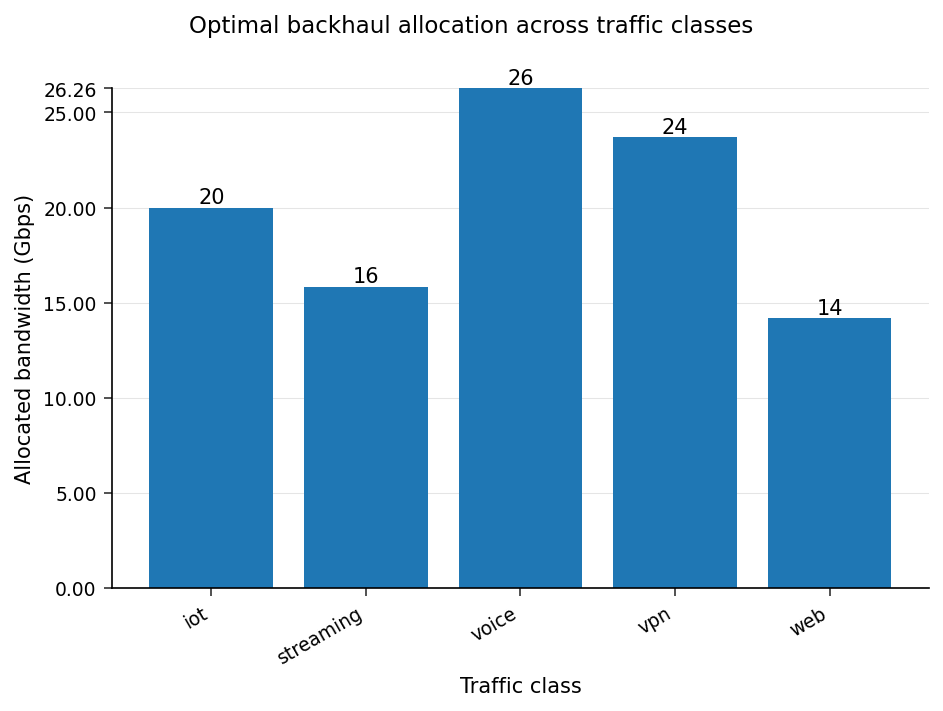

In [4]:
proc sgplot data=qp_alloc;
    title 'Optimal backhaul allocation across traffic classes';
    vbar traffic_class / response=gbps datalabel
         datalabelattrs=(size=9);
    yaxis label='Allocated bandwidth (Gbps)' grid;
    xaxis label='Traffic class';
run;

## Interpreting the results

`SOLVE WITH QP` reaches an **optimal** solution with objective value **-388.03**. Read
off the recommended plan and the structure behind it:

- **The link runs full.** The five allocations sum to exactly **100 Gbps**, so the
  `cap` constraint binds. Because every margin coefficient is negative, the operator
  always wants to carry more traffic; what stops it is the convex congestion penalty,
  and that balance lands precisely at the capacity ceiling.

- **IoT is held back by policy, not economics.** IoT sits at exactly **20.00 Gbps**, its
  policy cap — the `iot` constraint binds. Its low congestion curvature (0.20) and modest
  margin (-5.16) would otherwise let it grow further; the cap is what limits it, so
  relaxing the M2M policy is the lever to value next.

- **The floors are slack.** Voice settles at **26.26 Gbps** (far above its 12 Gbps
  regulatory floor) and VPN at **23.71 Gbps** (above its 15 Gbps SLA floor). The
  cost-minimizing plan already over-delivers on both obligations, so neither floor is
  costing the operator anything at the current optimum.

- **Diminishing returns balance the classes.** The quadratic diagonal terms
  (0.20–0.45) make each class's marginal congestion cost rise with its allocation, so no
  single class monopolizes the link. The streaming–web cross-term (0.10) further couples
  those two classes — loading both heavily is penalized — which keeps streaming
  (15.84 Gbps) and web (14.18 Gbps) close together rather than letting either dominate.

**What to vary next.** Because IoT and capacity are the binding constraints, the two most
informative re-runs are (a) raising the `cap` right-hand side to trace how much an
expanded backhaul lowers total cost, and (b) relaxing the `iot` cap to value additional
M2M headroom. Each is a one-line edit to the model above.